In [1]:
%matplotlib widget

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [2]:
input_dir1 = './MPD_events'
input_dir2 = '../answers'
input_dir3 = '../true_answers'

efficiency_list = [[] for _ in range(3)]
recovery_list = [[] for _ in range(3)]

for p, pt in enumerate([0, 0.05, 0.15]):
    for evtid in range(800, 1000):
        event_name = input_dir1 + f'/event_{evtid}_'
        answer_name = input_dir2 + f'/answer_{evtid}.csv'
        true_answer_name = input_dir3 + f'/answer_{evtid}.csv'
        print(f'Processing: {event_name:s}#.csv & {answer_name:s} & {true_answer_name:s}')

        tracks = pd.read_csv(event_name + 'tracks.csv')
        truth = pd.read_csv(event_name + 'truth.csv')
        rename = pd.read_csv(true_answer_name)

        truth = truth.merge(tracks, on='track_id')

        mapping = rename.set_index('hit_id')['track_id']
        truth['track_id'] = truth['hit_id'].map(mapping).fillna(truth['track_id'])

        pred = pd.read_csv(answer_name)

        if not truth.empty:      
            true_track_sizes = truth.groupby('track_id').size()
            track_pt = truth[['track_id', 'pt']].drop_duplicates('track_id').set_index('track_id')['pt']

            merged = truth[['hit_id', 'track_id', 'pt']].merge(
                pred, on='hit_id', how='inner', suffixes=('_true', '_pred')
            )      

            mode_mapping = merged.groupby('track_id_pred')['track_id_true'].agg(
                lambda x: x.mode().iloc[0] if not x.mode().empty else None
            )

            merged['assigned_true'] = merged['track_id_pred'].map(mode_mapping)
            merged['assigned_pt'] = merged['assigned_true'].map(track_pt)

            merged['is_correct'] = (merged['track_id_true'] == merged['assigned_true']).astype(int)

            merged = merged[merged['assigned_pt'] >= pt]

            if merged.empty:
                efficiency_list[p].append([])
                continue

            pred_true_sizes = merged.groupby('track_id_pred')['assigned_true'].first().map(true_track_sizes)

            correct_counts = merged.groupby('track_id_pred')['is_correct'].sum()
            efficiencies = correct_counts / pred_true_sizes.reindex(correct_counts.index)
            efficiency_list[p].append(efficiencies.tolist())

            unique_pred = merged['track_id_pred'].nunique()
            unique_true = merged['track_id_true'].nunique()
            recovery = unique_pred / unique_true if unique_true > 0 else 0.0
            recovery_list[p].append(recovery)

Processing: ./MPD_events/event_800_#.csv & ../answers/answer_800.csv & ../true_answers/answer_800.csv
Processing: ./MPD_events/event_801_#.csv & ../answers/answer_801.csv & ../true_answers/answer_801.csv
Processing: ./MPD_events/event_802_#.csv & ../answers/answer_802.csv & ../true_answers/answer_802.csv
Processing: ./MPD_events/event_803_#.csv & ../answers/answer_803.csv & ../true_answers/answer_803.csv
Processing: ./MPD_events/event_804_#.csv & ../answers/answer_804.csv & ../true_answers/answer_804.csv
Processing: ./MPD_events/event_805_#.csv & ../answers/answer_805.csv & ../true_answers/answer_805.csv
Processing: ./MPD_events/event_806_#.csv & ../answers/answer_806.csv & ../true_answers/answer_806.csv
Processing: ./MPD_events/event_807_#.csv & ../answers/answer_807.csv & ../true_answers/answer_807.csv
Processing: ./MPD_events/event_808_#.csv & ../answers/answer_808.csv & ../true_answers/answer_808.csv
Processing: ./MPD_events/event_809_#.csv & ../answers/answer_809.csv & ../true_ans

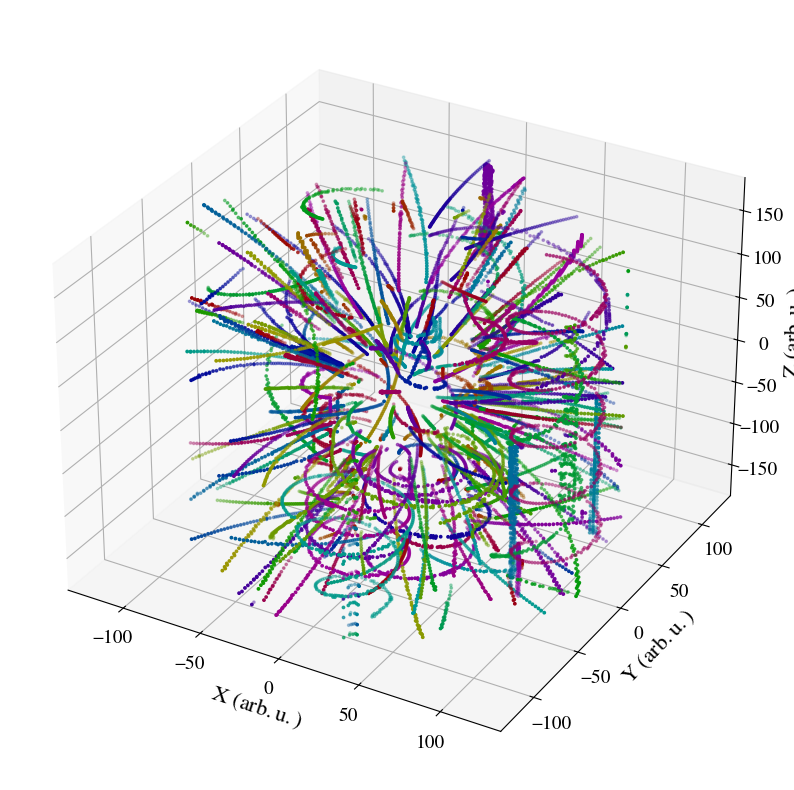

In [3]:
evtid = 801

input_dir1 = './MPD_events'
input_dir2 = '../answers'

event_name = input_dir1 + f'/event_{evtid}_'
answer_name = input_dir2 + f'/answer_{evtid}.csv'

hits = pd.read_csv(event_name + 'hits.csv')
pred = pd.read_csv(answer_name)

track_points = hits[['hit_id', 'x', 'y', 'z']].merge(
            pred, on='hit_id', how='inner', suffixes=('_true', '_pred')
        )

grouped = track_points.groupby('track_id')

unique_tracks = track_points['track_id'].unique()
num_tracks = len(unique_tracks)

hues = np.linspace(0, 1, num_tracks)
saturation = np.full(num_tracks, 1.0)
value = np.full(num_tracks, 0.6)

hsv = np.stack([hues, saturation, value], axis=1)
colors = mcolors.hsv_to_rgb(hsv)

with plt.rc_context({
    'font.family': 'Nimbus Roman',
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Nimbus Roman',
    'mathtext.it': 'Nimbus Roman:italic',
}):
    fig = plt.figure(figsize=(13, 10))
    ax = fig.add_subplot(111, projection='3d')

    for i, (track_id, group) in enumerate(grouped):
        ax.scatter(
            group['x'], group['y'], group['z'],
            c=[colors[i]], 
            marker='o',
            s=3,  
            label=f'Track {track_id}'
        )

    ax.set_xlabel(r'X ($\mathrm{arb.u.}$)', fontsize=16)
    ax.set_ylabel(r'Y ($\mathrm{arb.u.}$)', fontsize=16)
    ax.set_zlabel(r'Z ($\mathrm{arb.u.}$)', fontsize=16)
    ax.tick_params(axis='both', which='major', labelsize=14)
    
    plt.show()

In [3]:
xlist = list(range(50, 102, 2))

eff = [[0] * len(xlist) for _ in range(3)]

for p in range(3):
    for row in efficiency_list[p]:
        for i, x in enumerate(xlist):
            eff[p][i] += sum(1 for num in row if num >= x/100) / len(row) * 100

    for i in range(len(eff[p])):
        eff[p][i] /= len(efficiency_list[p])

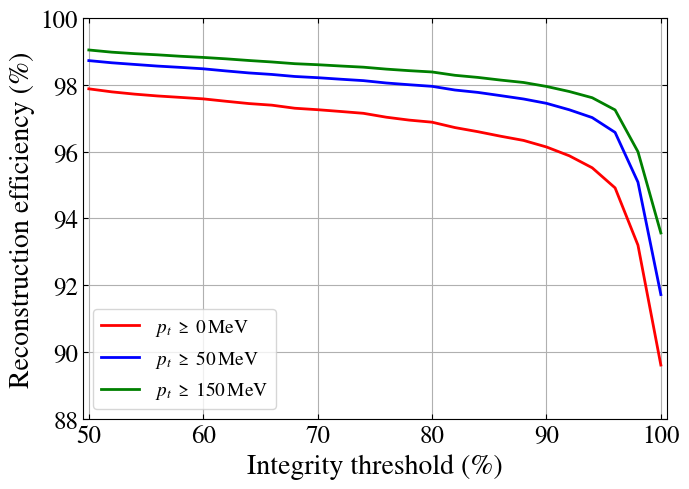

In [4]:
with plt.rc_context({
    'font.family': 'Nimbus Roman',
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Nimbus Roman',
    'mathtext.it': 'Nimbus Roman:italic',
}):
    plt.figure(figsize=(7, 5))
    plt.plot(xlist, eff[0], alpha=1, label=r'$p_t \geq \mathrm{0\,MeV}$', linewidth=2, color='red')
    plt.plot(xlist, eff[1], alpha=1, label=r'$p_t \geq \mathrm{50\,MeV}$', linewidth=2, color='blue')
    plt.plot(xlist, eff[2], alpha=1, label=r'$p_t \geq \mathrm{150\,MeV}$', linewidth=2, color='green')
    plt.xlim([49.5, 100.5])
    plt.ylim([88, 100])
    plt.xlabel('Integrity threshold (%)', fontsize=20)
    plt.ylabel('Reconstruction efficiency (%)', fontsize=20)
    plt.tick_params(axis='both', 
                    which='major', 
                    labelsize=18,
                    top=True,
                    bottom=True,
                    left=True,
                    right=True,
                    direction='in')
    plt.yticks(np.arange(88, 101, 2))
    plt.grid(True)
    plt.tight_layout()
    plt.legend(fontsize=14)
    plt.show()

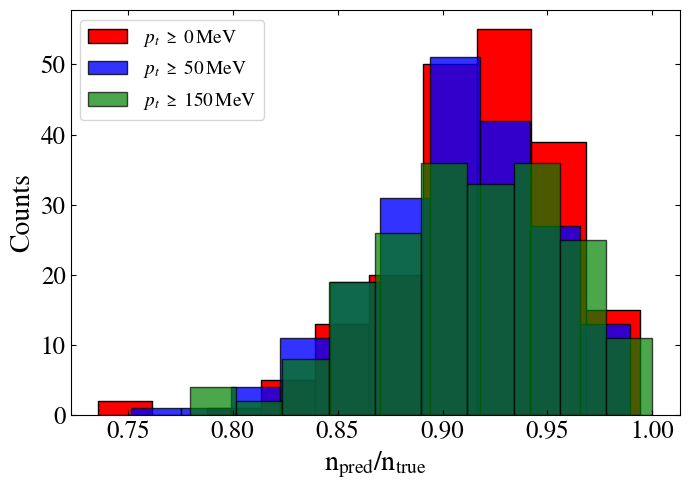

In [5]:
with plt.rc_context({
    'font.family': 'Nimbus Roman',
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Nimbus Roman',
    'mathtext.it': 'Nimbus Roman:italic',
}):
    plt.figure(figsize=(7, 5))
    plt.hist(recovery_list[0], edgecolor='black', alpha=1, label=r'$p_t \geq \mathrm{0\,MeV}$', color="red")
    plt.hist(recovery_list[1], edgecolor='black', alpha=0.8, label=r'$p_t \geq \mathrm{50\,MeV}$', color="blue")
    plt.hist(recovery_list[2], edgecolor='black', alpha=0.7, label=r'$p_t \geq \mathrm{150\,MeV}$', color="green")
    plt.xlabel(r'$\mathrm{n}_{\mathrm{pred}} / \mathrm{n}_{\mathrm{true}}$', fontsize=20)
    plt.ylabel('Counts', fontsize=20)
    plt.tick_params(axis='both', 
                    which='major', 
                    labelsize=18,
                    top=True,
                    bottom=True,
                    left=True,
                    right=True,
                    direction='in')
    plt.tight_layout()
    plt.legend(fontsize=14)
    plt.show()